# CIFAR-10 Image Colorization

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/O-2wice/cifar10-image-colorization/blob/main/notebooks/original-image-colorization.ipynb)
![Runtime](https://img.shields.io/badge/runtime-CPU%20or%20GPU-blue)
![Framework](https://img.shields.io/badge/framework-PyTorch-orange)

<img src="https://learnopencv.com/wp-content/uploads/2018/07/colorization-example.png" alt="Image colorization example" border="0">

This project explores image colorization as a supervised image-to-image learning problem. The model receives a grayscale image and predicts the corresponding RGB image.

The experiment compares two PyTorch models on CIFAR-10:

- **CNN colorizer:** a shallow convolutional network that keeps the image structure intact while learning local visual patterns.
- **Fully connected baseline:** a linear model that flattens each grayscale image before predicting RGB pixels.

The goal is to understand how model architecture affects reconstruction quality, training behavior, and qualitative colorization results.

## Project Workflow

The notebook follows the same end-to-end development flow as the original experiment:

1. Prepare the Python environment.
2. Load CIFAR-10.
3. Build grayscale/RGB image pairs.
4. Visualize the training data.
5. Define the CNN colorizer.
6. Define the fully connected baseline.
7. Compare model sizes.
8. Train both models with validation monitoring and checkpointing.
9. Plot learning curves and evaluate test loss.
10. Compare predictions visually.
11. Inspect CNN feature maps and fully connected layer weights.

## Project Scope

This notebook is intentionally compact and reproducible. CIFAR-10 is small enough to train quickly on a GPU while still containing natural image structure, object boundaries, textures, and varied colors.

The project is not meant to produce production-grade colorization. It is meant to show the full deep learning workflow: dataset preparation, model design, training, evaluation, and interpretation.

All experiments use real CIFAR-10 images. No synthetic replacement dataset is used for the portfolio result.

**Author:** Robert Ouko Oyombe

## Environment Setup

The notebook uses PyTorch for modeling, TorchVision for CIFAR-10, and Matplotlib for visual inspection. Training will use a GPU when one is available.

In [24]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import importlib.util
import random
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets

# A fixed seed makes the train/validation split and weight initialisation
# repeatable, so two runs of this notebook are comparable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Resolve paths from the repository root whether the notebook is launched from
# the project root, from notebooks/, or from /content on Colab.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Detect the runtime by whether the google.colab package is installed, rather
# than whether it is already imported. The browser frontend imports it during
# startup, but the VS Code Colab extension attaches a plain kernel to the same
# VM and does not, so a sys.modules check would miss a genuine Colab GPU.
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    # find_spec imports the parent package, which does not exist off Colab.
    IN_COLAB = False
# Mount Drive when it is available. It gives the dataset a cache that survives
# the runtime, which matters because the CIFAR-10 download can be slow, and it
# gives the trained artifacts somewhere to land that is not wiped with the VM.
#
# The mount needs a browser tab attached to the kernel. It works in browser
# Colab and fails from the VS Code extension, so the failure is not fatal:
# everything falls back to runtime-local paths.
DRIVE_DIR = None
if IN_COLAB:
    try:
        from google.colab import drive

        drive.mount("/content/drive")
        DRIVE_DIR = Path("/content/drive/MyDrive/cifar10-image-colorization")
        DRIVE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Drive mounted: {DRIVE_DIR}")
    except Exception as exc:
        print(f"Drive not mounted ({type(exc).__name__}). Using runtime-local paths.")

# Cache the dataset on Drive when possible. CIFAR-10 is stored as a handful of
# large pickle batches that torchvision reads once into memory, so the slower
# Drive read costs a few seconds and saves re-downloading 170 MB every session.
DATA_DIR = (DRIVE_DIR / "data") if DRIVE_DIR is not None else (PROJECT_ROOT / "data")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
accelerator = "GPU" if torch.cuda.is_available() else "CPU"
print(f"Runtime accelerator: {accelerator}")
print(f"Using device: {device}")
print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Running in Colab: {IN_COLAB}")
print(f"Dataset directory: {DATA_DIR}")


def summarize_model(model):
    """Print a model's layer structure and its parameter count."""
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(model)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted: /content/drive/MyDrive/cifar10-image-colorization
Runtime accelerator: GPU
Using device: cuda:0
Project root: /content
Running in Colab: True
Dataset directory: /content/drive/MyDrive/cifar10-image-colorization/data


## Data Loading Process

CIFAR-10 provides 60,000 small RGB images across 10 object categories. The labels are not used in this project; each image is treated as a color target, and a grayscale copy of the same image becomes the model input.

### Dataset: CIFAR-10

CIFAR-10 contains 50,000 training images and 10,000 test images. Each image is 32 x 32 pixels with three RGB channels.

That size makes the dataset useful for a first image-to-image experiment: the images are small enough for fast iteration, but still complex enough to reveal differences between the CNN and fully connected baseline.

In [25]:
# Load CIFAR-10 as raw PIL images. The paired dataset applies tensor conversion.
trainset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True)
testset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True)

print(f"Number of training samples: {len(trainset)}")
print(f"Number of test samples: {len(testset)}")

100%|██████████| 170M/170M [29:33<00:00, 96.1kB/s] 


Number of training samples: 50000
Number of test samples: 10000


## Preprocessing Strategy

The RGB target and the model prediction have to live on the same numeric scale.
Both models end in `sigmoid`, so their outputs can only fall in `[0, 1]`. The
targets are therefore produced with `ToTensor()` alone, which already yields
`[0, 1]`, and **no `Normalize()` is applied**.

The original coursework version normalized to `[-1, 1]`. A sigmoid cannot reach
the negative half of that range, so the MSE floored near `0.15` no matter how
long the models trained. Removing the normalization is what makes the loss values
in this notebook meaningful.

The grayscale conversion happens inside the custom dataset so every sample keeps
both versions of the same image:

- **input:** grayscale tensor of shape `[1, 32, 32]`
- **target:** RGB tensor of shape `[3, 32, 32]`

In [26]:
# CIFAR-10 ships as 32x32 images, so no resize step is needed; dropping it takes
# a redundant pass over every sample out of the data pipeline.
#
# Both transforms are applied to the *same* PIL image in the dataset below, which
# is what keeps each grayscale input aligned with its RGB target.
color_transform = transforms.ToTensor()

gray_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

## Grayscale-to-Color Dataset and DataLoaders

The custom dataset wraps CIFAR-10 and returns paired tensors for image colorization. Each batch contains grayscale inputs and RGB targets from the same original images.

The original CIFAR-10 training split is divided into a training subset and a validation subset. The held-out CIFAR-10 test split is only used for final evaluation after checkpoint selection.

In [27]:
class GrayscaleToColorDataset(Dataset):
    """Wrap an image dataset and return (grayscale input, RGB target) pairs.

    The CIFAR-10 class labels are discarded: this is a reconstruction task, so
    each image acts as its own supervision signal.
    """

    def __init__(self, dataset, gray_transform, color_transform):
        self.dataset = dataset
        self.gray_transform = gray_transform
        self.color_transform = color_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, _ = self.dataset[idx]
        return self.gray_transform(image), self.color_transform(image)


full_train_dataset = GrayscaleToColorDataset(trainset, gray_transform, color_transform)
test_dataset = GrayscaleToColorDataset(testset, gray_transform, color_transform)

# Hold out 5,000 training images for validation. Checkpoint selection and early
# stopping read only this split, which leaves the CIFAR-10 test split untouched
# until the final evaluation.
VALIDATION_SIZE = 5_000
training_size = len(full_train_dataset) - VALIDATION_SIZE
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [training_size, VALIDATION_SIZE],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 64

# The per-sample work here (PIL decode, grayscale conversion, two tensor casts)
# is CPU-bound, and on a GPU runtime it is the bottleneck rather than the model.
# Colab runs Linux, where worker processes fork cheaply and overlap that work
# with GPU compute. Windows spawns instead, and a spawned worker cannot unpickle
# a Dataset class defined inside a notebook, so local runs stay single-process.
NUM_WORKERS = 2 if IN_COLAB else 0
loader_options = {"num_workers": NUM_WORKERS, "pin_memory": device.type == "cuda"}
if NUM_WORKERS > 0:
    loader_options["persistent_workers"] = True

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **loader_options)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_options)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_options)

print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")
print(f"DataLoader workers: {NUM_WORKERS}")

Training samples:   45,000
Validation samples: 5,000
Test samples:       10,000
DataLoader workers: 2


## Visualizing Training Pairs

Before training, it is useful to inspect the input/target pairs. The first column shows the grayscale inputs seen by the models, and the second column shows the RGB targets they are trying to reconstruct.

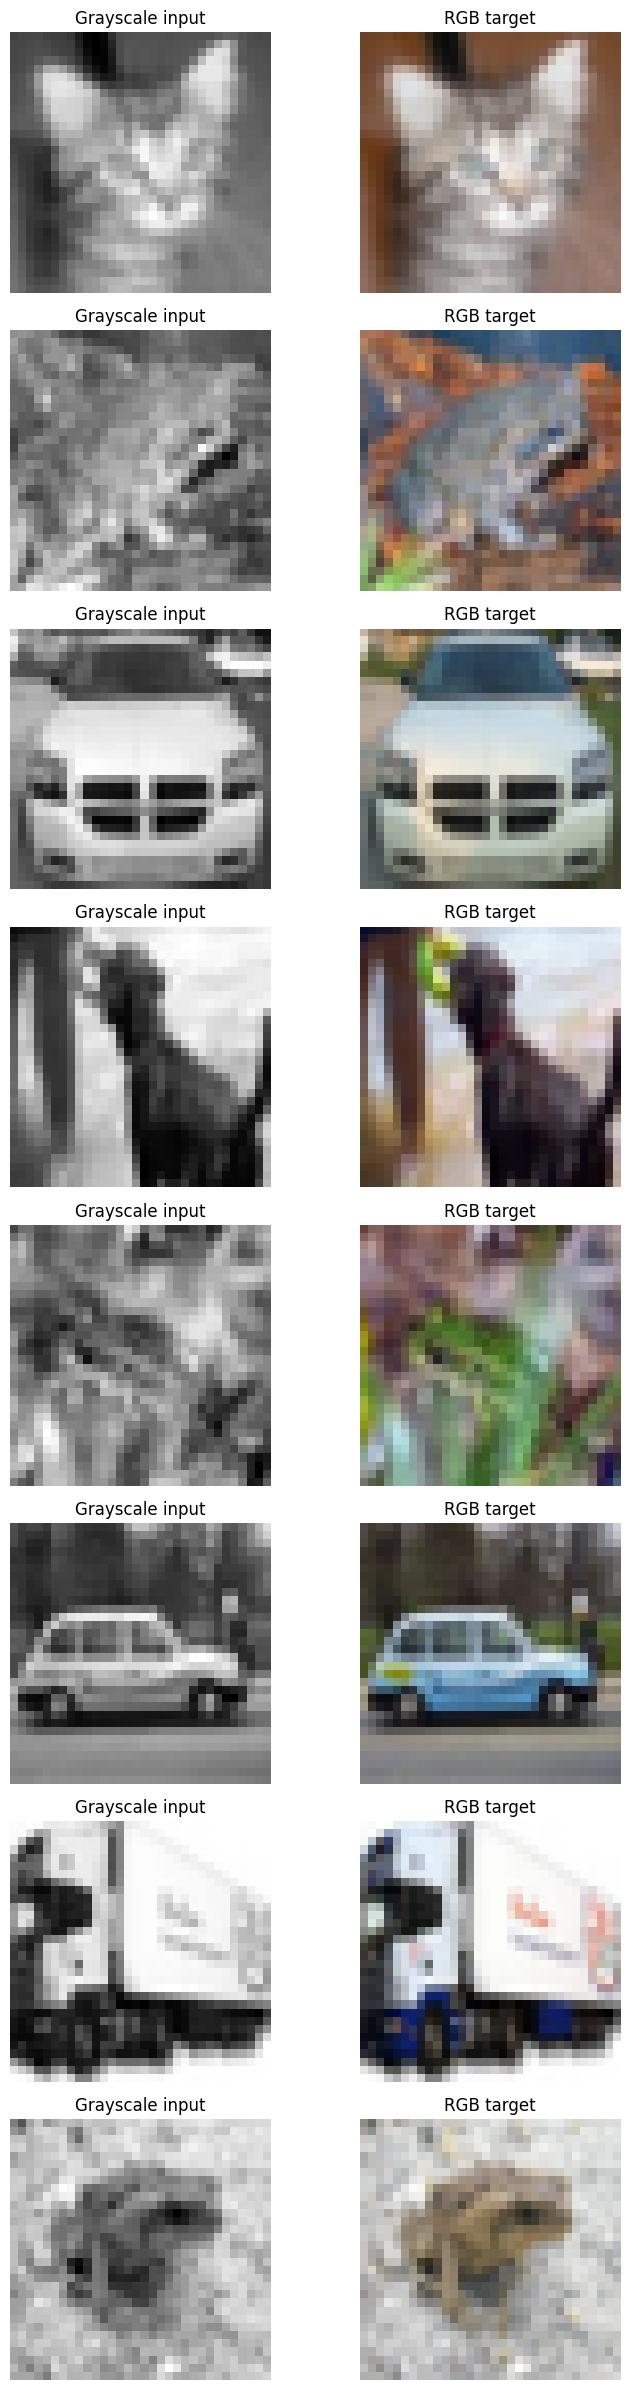

In [28]:
def visualize_batch(loader, rows=8):
    """Show grayscale inputs beside their RGB targets for one batch.

    Worth doing before training: it confirms the pairing is correct and that the
    target is the colour original rather than another grayscale copy.
    """
    gray_images, color_images = next(iter(loader))
    rows = min(rows, gray_images.size(0))

    gray_images = gray_images.numpy()
    color_images = color_images.numpy()

    fig, axes = plt.subplots(rows, 2, figsize=(8, 3 * rows))
    for i in range(rows):
        # Matplotlib wants [H, W, C]; torch delivers [C, H, W]. The squeeze drops
        # the single grayscale channel so imshow treats it as 2-D.
        gray_img = np.transpose(gray_images[i], (1, 2, 0)).squeeze()
        color_img = np.transpose(color_images[i], (1, 2, 0))

        axes[i, 0].imshow(gray_img, cmap="gray")
        axes[i, 0].set_title("Grayscale input")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(color_img)
        axes[i, 1].set_title("RGB target")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


visualize_batch(train_loader)

## CNN Colorization Model

The convolutional model processes the grayscale image as a spatial grid. Its convolutional layers learn local features such as edges, textures, and color-region cues, then produce a three-channel RGB prediction.

The final `sigmoid` keeps predicted pixel values between 0 and 1.

In [29]:
class ColorizationCNN(nn.Module):
    """Shallow convolutional colorizer: [N, 1, 32, 32] -> [N, 3, 32, 32].

    Every layer uses `padding=1` with a 3x3 kernel, so the spatial resolution is
    held at 32x32 from input to output. There is no downsampling: at this image
    size the network can afford to keep full resolution, and the task needs a
    colour decision at every pixel rather than a compressed global summary.
    """

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv2d(64, 3, kernel_size=3, padding=1)
        # Bounds the prediction to [0, 1], matching the ToTensor() target range.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.relu3(self.conv3(x))
        return self.sigmoid(self.conv4(x))

## Fully Connected Baseline

The baseline flattens each grayscale image into a vector, maps it directly to RGB pixels, and reshapes the result back to image form.

This model is intentionally simple. It gives the CNN a meaningful comparison point and shows what is lost when spatial structure is removed.

In [30]:
class ColorizationLinear(nn.Module):
    """Fully connected baseline: one linear map from 1,024 gray pixels to 3,072 RGB values.

    Flattening discards the grid layout, so this model has no notion of which
    pixels are neighbours. It has to learn every input-pixel/output-pixel
    relationship separately, which is the property being compared against the CNN.
    """

    def __init__(self, image_side=32):
        super().__init__()
        self.image_side = image_side
        self.fc1 = nn.Linear(image_side * image_side, 3 * image_side * image_side)

    def forward(self, x):
        x = x.view(x.size(0), -1)          # [N, 1, 32, 32] -> [N, 1024]
        x = self.fc1(x)                    # [N, 1024]      -> [N, 3072]
        # Fold the flat vector back into an image. The layer never saw the grid
        # structure, so this reshape is the only thing imposing it.
        x = x.view(x.size(0), 3, self.image_side, self.image_side)
        return torch.sigmoid(x)

## Model Size

Parameter counts help explain capacity and computational cost. The CNN shares filters spatially, while the fully connected baseline learns a direct pixel mapping from flattened grayscale inputs.

In [44]:
model_cnn = ColorizationCNN().to(device)
summarize_model(model_cnn)

ColorizationCNN(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (conv3): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (sigmoid): Sigmoid()
)
Total parameters: 150,019
Trainable parameters: 150,019


In [32]:
model_fcn = ColorizationLinear().to(device)
summarize_model(model_fcn)

ColorizationLinear(
  (fc1): Linear(in_features=1024, out_features=3072, bias=True)
)
Total parameters: 3,148,800
Trainable parameters: 3,148,800


## Loss Function and Optimizers

This is a regression task because the models predict continuous RGB pixel values. Mean squared error is used to measure the average pixel-level difference between each prediction and the ground-truth color image.

Both models are optimized with Adam at a learning rate of `0.001`. Separate optimizers and checkpoints are used so each model can train independently.

In [33]:
# MSE treats colorization as per-pixel regression: it penalises how far each
# predicted channel value sits from the true one.
criterion = nn.MSELoss()

LEARNING_RATE = 1e-3

# The baseline was still improving when a 10-epoch cap stopped it, so the cap
# was measuring the budget rather than the architecture. 20 gives both models
# room to converge; early stopping ends the CNN sooner, as it did before at
# epoch 9.
EPOCHS = 20
PATIENCE = 2
PROGRESS_EVERY = 100

optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE)
optimizer_fcn = optim.Adam(model_fcn.parameters(), lr=LEARNING_RATE)

# "best" holds the weights from the lowest validation loss and is what inference
# loads. "last" additionally carries optimizer state and history so an
# interrupted run can pick up where it stopped.
best_path_cnn = MODEL_DIR / "best_model_cnn.pth"
best_path_fcn = MODEL_DIR / "best_model_fcn.pth"
last_path_cnn = MODEL_DIR / "last_model_cnn.pth"
last_path_fcn = MODEL_DIR / "last_model_fcn.pth"

## Training the Image Colorization Models

The loop below records training and validation loss per epoch, stops early when
validation loss stalls, and keeps the best-scoring weights.

Two details matter for long GPU runs on Colab:

- **Every epoch writes a resume checkpoint** holding model weights, optimizer
  state and loss history. If the runtime disconnects at epoch 8, re-running the
  training cell continues from epoch 9 instead of starting over.
- **Each model trains in its own cell**, so a failure while training the
  baseline cannot cost you the CNN result.

The CIFAR-10 test split takes no part in checkpoint selection; it is only used
for the final evaluation further down.

In [34]:
def evaluate_loss(model, loader, criterion):
    """Return the mean per-sample MSE over `loader`.

    Weighting each batch by its size matters because the final batch of an epoch
    is usually short. A plain mean over batches would over-weight it, and the
    training and validation curves would not be measured on the same footing.
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for gray_images, color_images in loader:
            gray_images = gray_images.to(device, non_blocking=True)
            color_images = color_images.to(device, non_blocking=True)
            predictions = model(gray_images)
            total_loss += criterion(predictions, color_images).item() * gray_images.size(0)
            total_samples += gray_images.size(0)

    return total_loss / total_samples


def train_model(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    best_path,
    last_path,
    epochs=EPOCHS,
    patience=PATIENCE,
    progress_every=PROGRESS_EVERY,
):
    """Train one colorizer and return its {"train_loss", "val_loss"} history.

    Resumes automatically when `last_path` already exists, so an interrupted
    Colab session costs only the epoch that was in flight. Early stopping fires
    after `patience` epochs without a validation improvement.
    """
    history = {"train_loss": [], "val_loss": []}
    start_epoch = 0
    best_val_loss = float("inf")
    epochs_without_gain = 0

    if last_path.exists():
        checkpoint = torch.load(last_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        history = checkpoint["history"]
        start_epoch = checkpoint["epoch"]
        best_val_loss = checkpoint["best_val_loss"]
        epochs_without_gain = checkpoint["epochs_without_gain"]
        print(f"Resuming {last_path.name} at epoch {start_epoch + 1}/{epochs}.", flush=True)

    if start_epoch >= epochs:
        print(f"{last_path.name} already covers {epochs} epochs; nothing to do.", flush=True)
        return history

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        seen_samples = 0
        epoch_start = time.time()

        for batch_idx, (gray_images, color_images) in enumerate(train_loader, start=1):
            gray_images = gray_images.to(device, non_blocking=True)
            color_images = color_images.to(device, non_blocking=True)

            optimizer.zero_grad()
            predictions = model(gray_images)
            loss = criterion(predictions, color_images)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * gray_images.size(0)
            seen_samples += gray_images.size(0)

            if batch_idx == 1 or batch_idx % progress_every == 0 or batch_idx == len(train_loader):
                elapsed_min = (time.time() - epoch_start) / 60
                print(
                    f"Epoch {epoch + 1:02d}/{epochs} "
                    f"batch {batch_idx:04d}/{len(train_loader)} "
                    f"loss: {loss.item():.4f} "
                    f"elapsed: {elapsed_min:.1f} min",
                    flush=True,
                )

        train_loss = running_loss / seen_samples
        val_loss = evaluate_loss(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_gain = 0
            torch.save(model.state_dict(), best_path)
            status = f"validation improved, wrote {best_path.name}"
        else:
            epochs_without_gain += 1
            status = f"no improvement ({epochs_without_gain}/{patience})"

        # Written every epoch, improvement or not: this is the resume point.
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "history": history,
                "best_val_loss": best_val_loss,
                "epochs_without_gain": epochs_without_gain,
            },
            last_path,
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} complete | "
            f"train {train_loss:.4f} | val {val_loss:.4f} | {status}",
            flush=True,
        )

        if epochs_without_gain >= patience:
            print(f"Early stopping after {patience} epochs without improvement.", flush=True)
            break

    return history

### Train the CNN colorizer

In [35]:
# Safe to re-run: picks up from the last completed epoch if it was interrupted.
history_cnn = train_model(
    model_cnn,
    optimizer_cnn,
    criterion,
    train_loader,
    val_loader,
    best_path=best_path_cnn,
    last_path=last_path_cnn,
)

Resuming last_model_cnn.pth at epoch 10/20.
Epoch 10/20 batch 0001/704 loss: 0.0061 elapsed: 0.0 min
Epoch 10/20 batch 0100/704 loss: 0.0039 elapsed: 0.0 min
Epoch 10/20 batch 0200/704 loss: 0.0052 elapsed: 0.1 min
Epoch 10/20 batch 0300/704 loss: 0.0072 elapsed: 0.1 min
Epoch 10/20 batch 0400/704 loss: 0.0067 elapsed: 0.2 min
Epoch 10/20 batch 0500/704 loss: 0.0067 elapsed: 0.2 min
Epoch 10/20 batch 0600/704 loss: 0.0050 elapsed: 0.2 min
Epoch 10/20 batch 0700/704 loss: 0.0052 elapsed: 0.3 min
Epoch 10/20 batch 0704/704 loss: 0.0047 elapsed: 0.3 min
Epoch 10/20 complete | train 0.0054 | val 0.0056 | validation improved, wrote best_model_cnn.pth
Epoch 11/20 batch 0001/704 loss: 0.0053 elapsed: 0.0 min
Epoch 11/20 batch 0100/704 loss: 0.0050 elapsed: 0.0 min
Epoch 11/20 batch 0200/704 loss: 0.0056 elapsed: 0.1 min
Epoch 11/20 batch 0300/704 loss: 0.0053 elapsed: 0.1 min
Epoch 11/20 batch 0400/704 loss: 0.0046 elapsed: 0.2 min
Epoch 11/20 batch 0500/704 loss: 0.0055 elapsed: 0.2 min
Epoc

### Train the fully connected baseline

In [36]:
history_fcn = train_model(
    model_fcn,
    optimizer_fcn,
    criterion,
    train_loader,
    val_loader,
    best_path=best_path_fcn,
    last_path=last_path_fcn,
)

Resuming last_model_fcn.pth at epoch 11/20.
Epoch 11/20 batch 0001/704 loss: 0.0084 elapsed: 0.0 min
Epoch 11/20 batch 0100/704 loss: 0.0068 elapsed: 0.0 min
Epoch 11/20 batch 0200/704 loss: 0.0080 elapsed: 0.1 min
Epoch 11/20 batch 0300/704 loss: 0.0074 elapsed: 0.1 min
Epoch 11/20 batch 0400/704 loss: 0.0084 elapsed: 0.1 min
Epoch 11/20 batch 0500/704 loss: 0.0074 elapsed: 0.1 min
Epoch 11/20 batch 0600/704 loss: 0.0080 elapsed: 0.2 min
Epoch 11/20 batch 0700/704 loss: 0.0075 elapsed: 0.2 min
Epoch 11/20 batch 0704/704 loss: 0.0088 elapsed: 0.2 min
Epoch 11/20 complete | train 0.0074 | val 0.0076 | validation improved, wrote best_model_fcn.pth
Epoch 12/20 batch 0001/704 loss: 0.0060 elapsed: 0.0 min
Epoch 12/20 batch 0100/704 loss: 0.0074 elapsed: 0.0 min
Epoch 12/20 batch 0200/704 loss: 0.0073 elapsed: 0.1 min
Epoch 12/20 batch 0300/704 loss: 0.0070 elapsed: 0.1 min
Epoch 12/20 batch 0400/704 loss: 0.0083 elapsed: 0.1 min
Epoch 12/20 batch 0500/704 loss: 0.0074 elapsed: 0.1 min
Epoc

### Save history and load the best checkpoints

In [45]:
# Persist the curves for the Quarto report, then load the best-scoring weights
# back into each model for the evaluation cells below.
history = {"cnn": history_cnn, "fcn": history_fcn}

with (METRIC_DIR / "training_history.json").open("w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

# Echo the history into the cell output as well. When training resumes from a
# checkpoint, the per-epoch log only covers the epochs this run executed, so the
# printed log alone understates the curve. This block is the complete record and
# travels home inside the saved notebook even if the files stay on the runtime.
print("HISTORY_JSON_BEGIN")
print(json.dumps(history))
print("HISTORY_JSON_END")

model_cnn.load_state_dict(torch.load(best_path_cnn, map_location=device))
model_cnn.eval()

model_fcn.load_state_dict(torch.load(best_path_fcn, map_location=device))
model_fcn.eval()

print("Loaded the best CNN and FCN checkpoints.")

HISTORY_JSON_BEGIN
{"cnn": {"train_loss": [0.007317985908024841, 0.006012472217612796, 0.005816118151611752, 0.005655964513288604, 0.005600459598667092, 0.005542125346759955, 0.005501922595666515, 0.005458521916137801, 0.005441155111458567, 0.005411387402067582, 0.005396107350703743, 0.005381901283396615, 0.005358725388182534, 0.005358547459170223, 0.005338584938562579], "val_loss": [0.006175731618702412, 0.006020237030088901, 0.005916043376922607, 0.0058481902420520785, 0.005635451272130013, 0.005802639538049698, 0.005586024852097035, 0.005715978647768498, 0.005613485226035118, 0.005568263481557369, 0.005512850612401962, 0.005557980239391327, 0.005479668784141541, 0.005515178252756596, 0.005604895001649857]}, "fcn": {"train_loss": [0.02793357700606187, 0.01838082390361362, 0.014445586734347874, 0.011992845032612482, 0.010383724171585507, 0.009321249792310927, 0.008568921301762263, 0.008119192107104593, 0.007794478856854969, 0.007605328194797039, 0.007420745093623797, 0.007318481439020

## Training Curves and Convergence

After training, the best checkpoints are loaded and the learning curves are plotted. The curves show whether loss decreases, plateaus, or begins to diverge between training and validation.

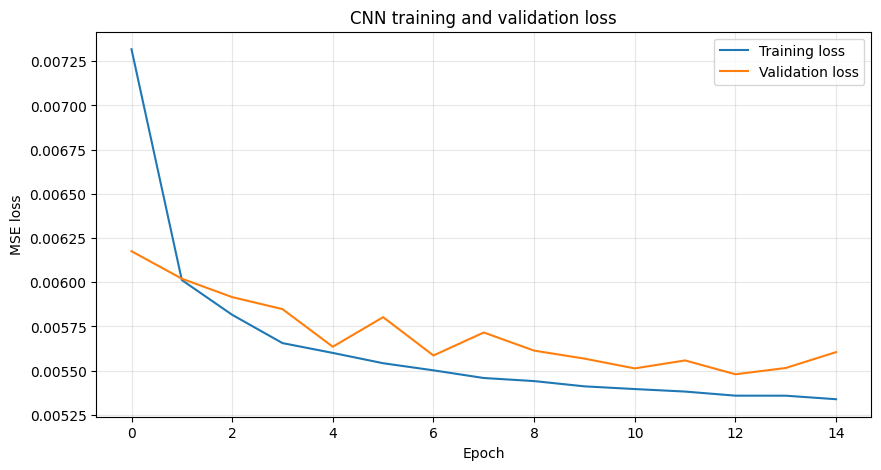

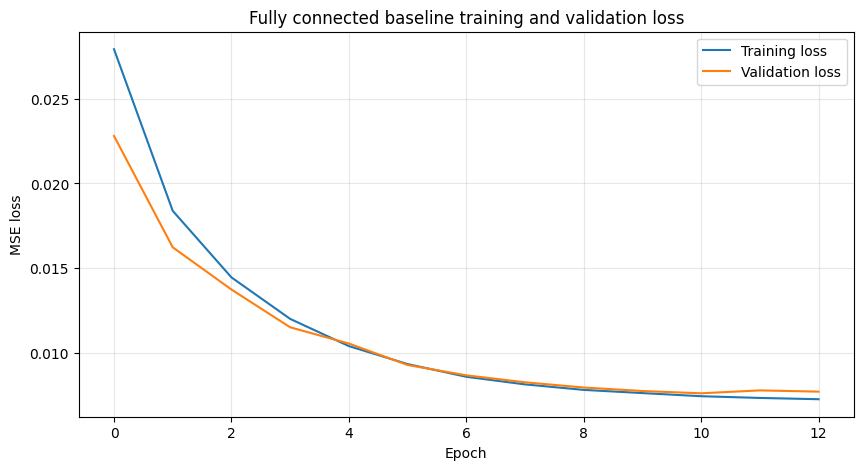

In [38]:
def plot_loss_curves(history, title):
    """Plot training and validation MSE against epoch for one model."""
    plt.figure(figsize=(10, 5))
    plt.plot(history["train_loss"], label="Training loss", color="tab:blue")
    plt.plot(history["val_loss"], label="Validation loss", color="tab:orange")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_loss_curves(history_cnn, "CNN training and validation loss")
plot_loss_curves(history_fcn, "Fully connected baseline training and validation loss")

## Training Observations

After running the training cell, both curves should be read together:

- a decreasing training curve shows that the model is learning from the training split
- a decreasing or stable validation curve suggests the learned mapping generalizes beyond the training examples
- a widening gap between training and validation loss would suggest overfitting

The CNN is expected to be a stronger fit for this task because convolutional filters reuse local visual patterns across the image. The fully connected baseline is useful because it shows what happens when the image is flattened and spatial structure is not built into the model.

## Inference and Test Loss

The trained checkpoints are evaluated on the CIFAR-10 test set. Test loss gives a numerical comparison of reconstruction quality on images that were not used for weight updates.

In [39]:
# evaluate_loss already computes a sample-weighted mean MSE over any loader, so
# the test set needs no separate implementation. Reusing it also guarantees the
# test figure is measured exactly like the validation figure it is compared to.
test_loss_cnn = evaluate_loss(model_cnn, test_loader, criterion)
test_loss_fcn = evaluate_loss(model_fcn, test_loader, criterion)

results = {
    "cnn_test_loss": test_loss_cnn,
    "fcn_test_loss": test_loss_fcn,
}

with (METRIC_DIR / "test_results.json").open("w", encoding="utf-8") as file:
    json.dump(results, file, indent=2)

print(f"Test Loss for CNN model: {test_loss_cnn:.4f}")
print(f"Test Loss for FCN model: {test_loss_fcn:.4f}")

Test Loss for CNN model: 0.0053
Test Loss for FCN model: 0.0074


## Qualitative Prediction Comparison

The next visualization compares grayscale inputs, model predictions, and ground-truth RGB images. Quantitative loss is useful, but visual inspection is important because colorization quality is partly perceptual.

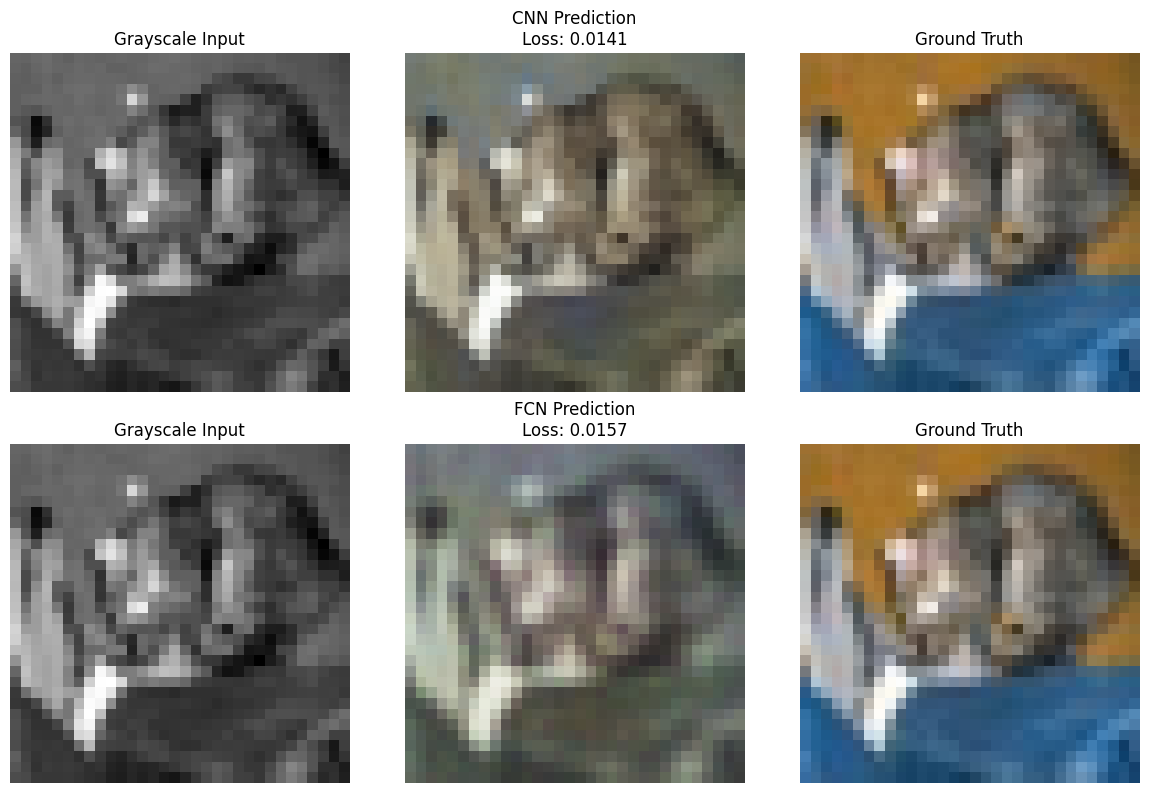

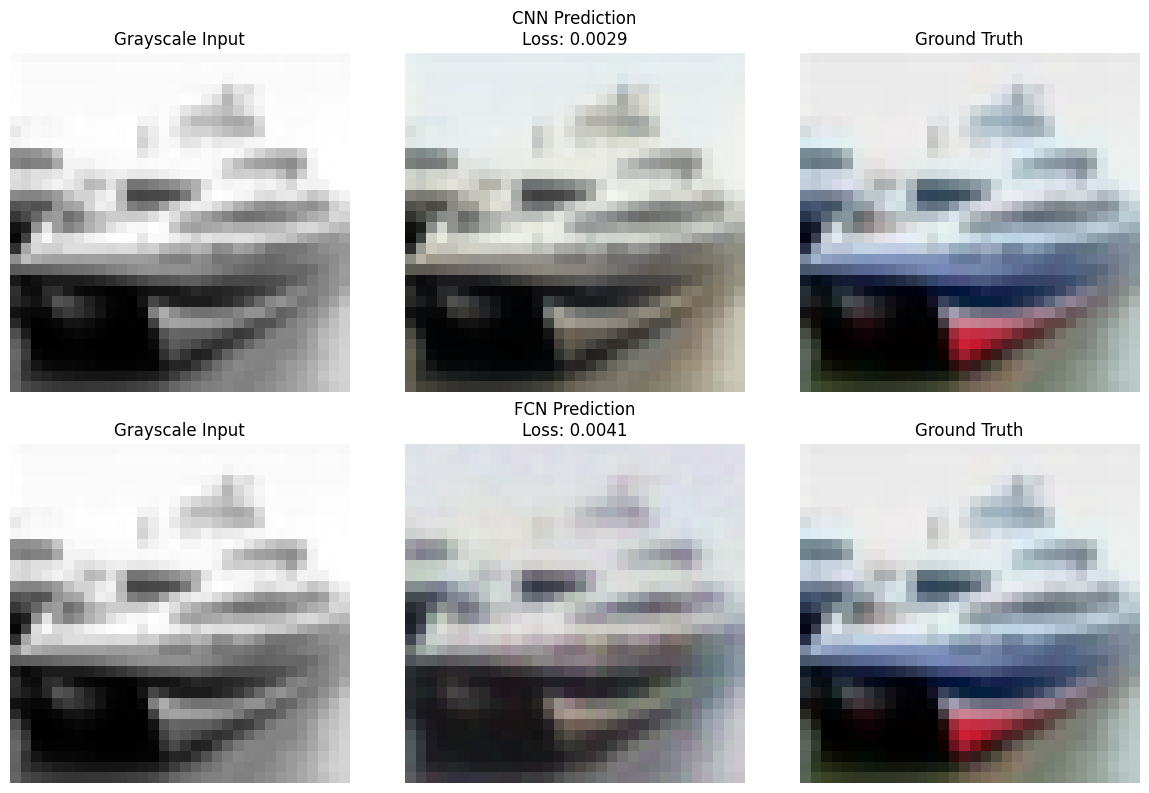

In [40]:
def plot_predictions(model_cnn, model_fcn, test_loader, criterion, num_images=2):
    """Compare both models against the ground truth on individual test images.

    One row per model: grayscale input, prediction, target. Test MSE says which
    model is closer on average; these panels show what that difference looks
    like, which matters because colour quality is partly a perceptual judgement.
    """
    model_cnn.eval()
    model_fcn.eval()

    with torch.no_grad():
        shown = 0
        for gray_images, color_images in test_loader:
            gray_images = gray_images.to(device)
            color_images = color_images.to(device)

            cnn_outputs = model_cnn(gray_images)
            fcn_outputs = model_fcn(gray_images)

            for sample_idx in range(gray_images.size(0)):
                if shown >= num_images:
                    return

                gray_img = gray_images[sample_idx].cpu().numpy().squeeze()
                color_img = color_images[sample_idx].cpu().numpy().transpose((1, 2, 0))
                cnn_pred = cnn_outputs[sample_idx].cpu().numpy().transpose((1, 2, 0))
                fcn_pred = fcn_outputs[sample_idx].cpu().numpy().transpose((1, 2, 0))

                # Slice rather than index so the tensor keeps its batch
                # dimension: MSELoss would otherwise average over a different
                # shape and report a figure for the wrong thing.
                cnn_loss = criterion(cnn_outputs[sample_idx:sample_idx + 1], color_images[sample_idx:sample_idx + 1])
                fcn_loss = criterion(fcn_outputs[sample_idx:sample_idx + 1], color_images[sample_idx:sample_idx + 1])

                # Sigmoid keeps values inside [0, 1] already; the clip guards
                # against float error tripping imshow's range check.
                cnn_pred = np.clip(cnn_pred, 0, 1)
                fcn_pred = np.clip(fcn_pred, 0, 1)
                color_img = np.clip(color_img, 0, 1)

                fig, axes = plt.subplots(2, 3, figsize=(12, 8))

                axes[0, 0].imshow(gray_img, cmap="gray")
                axes[0, 0].set_title("Grayscale Input")
                axes[0, 0].axis("off")

                axes[0, 1].imshow(cnn_pred)
                axes[0, 1].set_title(f"CNN Prediction\nLoss: {cnn_loss.item():.4f}")
                axes[0, 1].axis("off")

                axes[0, 2].imshow(color_img)
                axes[0, 2].set_title("Ground Truth")
                axes[0, 2].axis("off")

                axes[1, 0].imshow(gray_img, cmap="gray")
                axes[1, 0].set_title("Grayscale Input")
                axes[1, 0].axis("off")

                axes[1, 1].imshow(fcn_pred)
                axes[1, 1].set_title(f"FCN Prediction\nLoss: {fcn_loss.item():.4f}")
                axes[1, 1].axis("off")

                axes[1, 2].imshow(color_img)
                axes[1, 2].set_title("Ground Truth")
                axes[1, 2].axis("off")

                plt.tight_layout()
                plt.show()
                shown += 1

plot_predictions(model_cnn, model_fcn, test_loader, criterion, num_images=2)

## Interpreting Model Performance

The comparison combines the test losses with the prediction plots. This helps connect the architectural difference between the CNN and the fully connected baseline to the visual behavior of each model.

## Performance Interpretation

Use the printed test losses above as the numerical comparison for the current run. The better model is the one with the lower held-out test MSE.

Qualitatively, the CNN predictions should preserve image structure more consistently because convolutional layers process local neighborhoods. The fully connected baseline can learn a broad mapping from grayscale intensity to RGB values, but flattening removes the built-in spatial bias that helps with edges, textures, and coherent regions.

Both models remain limited. CIFAR-10 images are tiny, and grayscale-to-color mapping is inherently ambiguous: several colors can be plausible for the same luminance pattern. Better results would likely require a deeper architecture, skip connections, perceptual losses, or a color space such as Lab.

## Visualizing CNN Feature Maps

Feature maps show how the trained CNN transforms a grayscale input through its convolutional layers. The plots below capture activations from the trained colorization model rather than a newly initialized network.

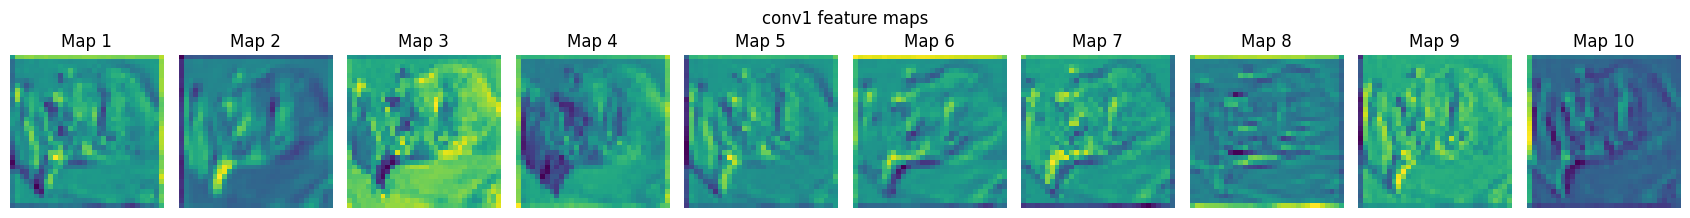

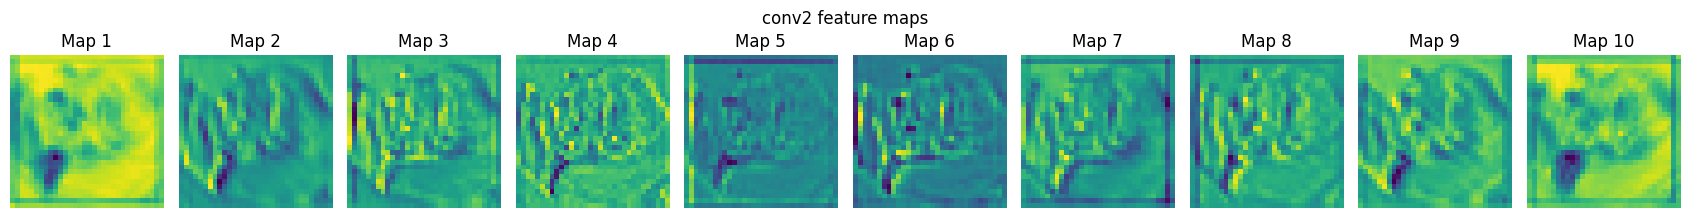

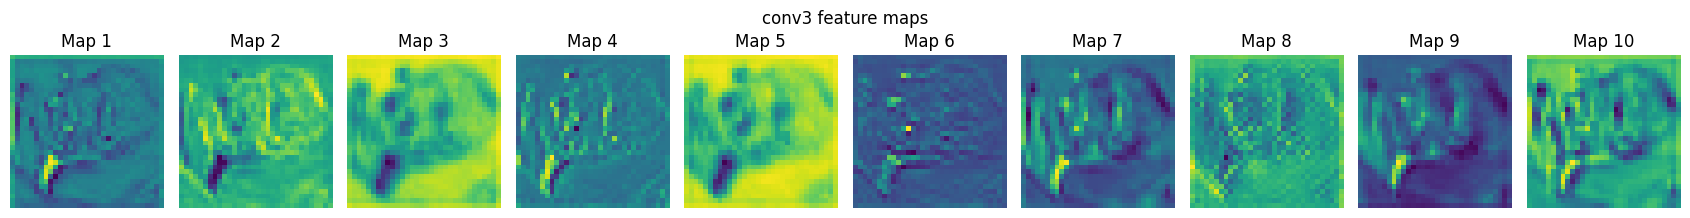

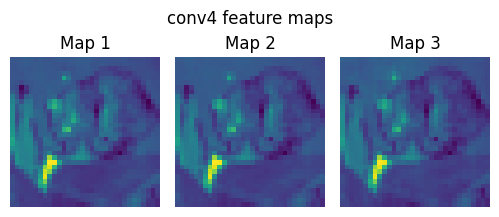

In [41]:
def visualize_feature_maps(model, loader, max_features=10):
    """Plot the activations each convolutional layer produces for one image.

    Forward hooks capture the output of every Conv2d as the sample passes
    through. The hooks are removed afterwards, since a registered hook keeps
    firing on every later forward pass and would leak memory into evaluation.

    Early layers respond to edges and local contrast; later ones combine those
    into the colour decision the final layer emits.
    """
    model.eval()
    captured = []
    hooks = []
    layer_names = []

    def capture(_module, _inputs, output):
        # Detach and move to CPU immediately: keeping the graph alive here would
        # hold the whole forward pass in GPU memory.
        captured.append(output.detach().cpu())

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            hooks.append(module.register_forward_hook(capture))
            layer_names.append(name)

    gray_images, _ = next(iter(loader))
    sample = gray_images[:1].to(device)

    with torch.no_grad():
        model(sample)

    for hook in hooks:
        hook.remove()

    for layer_name, feature_map in zip(layer_names, captured):
        feature_map = feature_map.squeeze(0).numpy()
        num_features = min(max_features, feature_map.shape[0])

        fig, axes = plt.subplots(1, num_features, figsize=(1.7 * num_features, 2.2))
        if num_features == 1:
            axes = [axes]

        for j in range(num_features):
            axes[j].imshow(feature_map[j], cmap="viridis")
            axes[j].set_title(f"Map {j + 1}")
            axes[j].axis("off")

        plt.suptitle(f"{layer_name} feature maps")
        plt.tight_layout()
        plt.show()


visualize_feature_maps(model_cnn, test_loader)

## Visualizing Fully Connected Weights

`fc1` is the baseline's only layer, so these are output weights rather than
hidden-feature detectors: row `i` of the weight matrix holds the 1,024
coefficients that output value `i` applies to the grayscale input.

Reshaping a row back to `32 x 32` therefore answers a specific question: *which
input pixels does this one output value read from?* Because the target colour at
a pixel is dominated by the brightness at that same pixel, the expected pattern
is a bright spot at the matching location on an otherwise flat field, not the
edge and texture detectors seen in a hidden layer of a deeper network.

The localized response tells us what the baseline learned: a near per-pixel
intensity-to-colour lookup, without the spatial context a convolution has built
into its structure.

In [ ]:
def visualize_fcn_weights(model, num_units=10, window=4, trace_units=96):
    """Show that each FCN output reads essentially one input pixel.

    fc1 is the baseline's only layer, so row i holds the 1,024 coefficients that
    output value i applies to the grayscale image.

    Plotting a full 32x32 row is useless here: 1,023 of its 1,024 cells sit near
    zero, so the image is a flat field whatever colormap is chosen, and the one
    cell that matters is a speck. Two views work better.

    The top row crops a window around each output's strongest weight, which is
    large enough to show the peak and whatever surround sits next to it. The
    lower panel plots that peak's location against the output index across many
    outputs: a straight diagonal means output i reads input pixel i, which is
    the per-pixel lookup this baseline settles into.
    """
    weights = model.fc1.weight.detach().cpu().numpy()
    side = model.image_side
    pixels = side * side

    num_units = min(num_units, weights.shape[0])
    trace_units = min(trace_units, weights.shape[0])
    peaks = np.abs(weights[:trace_units]).argmax(axis=1)
    span = 2 * window + 1

    fig = plt.figure(figsize=(1.55 * num_units, 5.2))
    grid = fig.add_gridspec(2, num_units, height_ratios=[1, 1.15], hspace=0.45)
    limit = float(np.abs(weights[:num_units]).max())

    for unit in range(num_units):
        row, col = divmod(int(peaks[unit]), side)
        # Shift the window at the edges rather than truncating it, so every
        # crop is the same size and they stay visually comparable.
        r0 = min(max(0, row - window), max(0, side - span))
        c0 = min(max(0, col - window), max(0, side - span))
        patch = weights[unit].reshape(side, side)[r0:r0 + span, c0:c0 + span]

        ax = fig.add_subplot(grid[0, unit])
        image = ax.imshow(patch, cmap="RdBu_r", vmin=-limit, vmax=limit)
        ax.set_title(f"Output {unit + 1}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(image, ax=fig.axes[:num_units], fraction=0.02, pad=0.01, label="weight")

    ax = fig.add_subplot(grid[1, :])
    ax.plot(range(trace_units), peaks, "o", markersize=3, label="strongest input pixel")
    ax.plot(range(trace_units), [o % pixels for o in range(trace_units)],
            "-", linewidth=1, label="matching pixel (output index)")
    ax.set_xlabel("output index")
    ax.set_ylabel("input pixel")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

    fig.suptitle(f"FCN first-layer weights, {span}x{span} crops around each peak")
    plt.show()

    matches = int(sum(int(peaks[o]) == o % pixels for o in range(trace_units)))
    print(f"Outputs whose strongest input is the matching pixel: {matches}/{trace_units}")


visualize_fcn_weights(model_fcn)


## Saving Results

Everything under `/content` is wiped when the runtime is recycled, so the
checkpoints and metrics have to leave the machine before the session ends.

If Drive mounted during setup, the archive is copied there and there is nothing
else to do. Otherwise the cell reports where the archive sits on the runtime, and
it has to be collected manually before the session ends.

The archive holds the metrics and the two best checkpoints. The per-epoch resume
files are excluded: they also carry optimizer state, which triples their size and
is of no use once training has finished.

In [43]:
import shutil

# The report needs the metrics JSON and the two best checkpoints. The per-epoch
# resume files also carry Adam optimizer state, which triples their size and is
# useless once training has finished, so they are left out of the archive.
RESUME_PREFIX = "last_model_"


def save_outputs(output_dir=OUTPUT_DIR, drive_dir=None):
    """Archive the results and report, honestly, where they ended up.

    Returns the path the archive can be collected from, or None if there was
    nothing to archive.
    """
    if not any(output_dir.rglob("*")):
        print(f"Nothing to archive: {output_dir} is empty. Run the training cells first.")
        return None

    staging = Path("/tmp/colorization-artifacts") if IN_COLAB else output_dir.parent / "_staging"
    if staging.exists():
        shutil.rmtree(staging)
    shutil.copytree(
        output_dir, staging,
        ignore=shutil.ignore_patterns(f"{RESUME_PREFIX}*"),
    )

    archive_path = Path(shutil.make_archive(
        str(Path.cwd() / "image-colorization-outputs"), "zip", staging
    ))
    shutil.rmtree(staging, ignore_errors=True)
    print(f"Archived {archive_path.name} ({archive_path.stat().st_size / 1024 ** 2:.1f} MB)")

    if drive_dir is not None:
        destination = Path(drive_dir) / archive_path.name
        shutil.copy2(archive_path, destination)
        print(f"Copied to Drive: {destination}")
        return destination

    if not IN_COLAB:
        print(f"Archive written to: {archive_path}")
        return archive_path

    # files.download() only works when a Colab browser tab is driving the
    # kernel. From the VS Code extension it queues JavaScript that never runs,
    # so it cannot be treated as a success: say what happened instead.
    try:
        from google.colab import files

        files.download(str(archive_path))
        print("Requested a browser download.")
        print("If no download appeared, this kernel has no browser attached.")
    except Exception as exc:
        print(f"Browser download unavailable ({type(exc).__name__}).")

    print()
    print(f"The archive is on the runtime at: {archive_path}")
    print("Verify it arrived before ending the session. If it did not, either")
    print("mount Drive above and re-run this cell, or open the same notebook in")
    print("browser Colab, where the direct download works.")
    return archive_path


save_outputs(drive_dir=DRIVE_DIR)


Archived image-colorization-outputs.zip (11.7 MB)
Copied to Drive: /content/drive/MyDrive/cifar10-image-colorization/image-colorization-outputs.zip


PosixPath('/content/drive/MyDrive/cifar10-image-colorization/image-colorization-outputs.zip')